In [1]:
import importlib.util
import subprocess
import sys

packages = [
    "kagglehub",
    "timm>=1.0.0",
    "torchmetrics",
    "ultralytics>=8.4.0",
    "onnx",
    "onnxscript",
    "ipywidgets",
]

def import_name_for(package_spec: str) -> str:
    package = package_spec.split(">=")[0].split("==")[0].split("<")[0]
    return {
        "ultralytics": "ultralytics",
        "torchmetrics": "torchmetrics",
        "onnxscript": "onnxscript",
        "kagglehub": "kagglehub",
        "ipywidgets": "ipywidgets",
    }.get(package, package.replace("-", "_"))

missing = [pkg for pkg in packages if importlib.util.find_spec(import_name_for(pkg)) is None]
if missing:
    print("Installing missing dependencies:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", *missing])
else:
    print("All training dependencies are already available.")

All training dependencies are already available.


In [2]:
import gc
import hashlib
import json
import os
import random
import re
import shutil
import subprocess
import time
from pathlib import Path

os.environ.setdefault("HF_HUB_DISABLE_IMPLICIT_TOKEN", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from IPython.display import display
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm
from ultralytics import YOLO

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 240)

SEED = 42
REPEATS = 3

def reset_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    try:
        torch.use_deterministic_algorithms(False)
    except Exception:
        pass
    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

reset_all_seeds(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "uynnhy" / "processed-images"
OUTPUT_DIR = PROJECT_ROOT / "final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
YOLO_DATA_DIR = OUTPUT_DIR / "yolo_dataset"
YOLO_RUNS_DIR = OUTPUT_DIR / "yolo_runs"
REPORT_DIR = OUTPUT_DIR / "reports"
PLOT_DIR = OUTPUT_DIR / "plots"
MANIFEST_PATH = REPORT_DIR / "fixed_split_manifest_seed42.csv"

for directory in [CHECKPOINT_DIR, YOLO_DATA_DIR, YOLO_RUNS_DIR, REPORT_DIR, PLOT_DIR, DATASET_ROOT.parent]:
    directory.mkdir(parents=True, exist_ok=True)

CLASS_DIRS = ["1. Healthy", "2. BG", "3. WSSV", "4. WSSV_BG"]
CLASS_NAMES = ["Healthy", "BG", "WSSV", "WSSV_BG"]
CLASS_TO_IDX = {folder: idx for idx, folder in enumerate(CLASS_DIRS)}
NUM_CLASSES = len(CLASS_DIRS)

IMG_SIZE = 224
EPOCHS = 30
PATIENCE = 15
PAPER_BATCH_SIZE = 128
MICRO_BATCH_SIZE = 32
ACCUMULATION_STEPS = max(1, PAPER_BATCH_SIZE // MICRO_BATCH_SIZE)
EVAL_BATCH_SIZE = PAPER_BATCH_SIZE
YOLO_BATCH_SIZE = PAPER_BATCH_SIZE
WARMUP_EPOCHS = 5
WARMUP_HEAD_LR = 1e-3
BACKBONE_FINETUNE_LR = 2e-5
HEAD_FINETUNE_LR = 1e-4
STEP_SIZE = 3
STEP_GAMMA = 0.9
NUM_WORKERS = min(8, max(2, (os.cpu_count() or 4) // 2))
ENABLE_GPU_LOGGING = True
GPU_LOG_EVERY_N_EPOCHS = 1
USE_AMP = torch.cuda.is_available()
AMP_DTYPE = torch.float16
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

TIMM_MODELS = ["convnext_tiny"]
YOLO_MODELS = ["yolo26m-cls"]
LOSS_RUNS = ["baseline_ce", "asl"]

LOSS_LABELS = {
    "baseline_ce": "Baseline CE",
    "asl": "ASL",
}

LOSS_PAPERS = {
    "baseline_ce": "Default CrossEntropyLoss",
    "asl": "Asymmetric Loss For Multi-Label Classification",
}

def has_class_folders(path: Path) -> bool:
    return all((path / class_dir).exists() for class_dir in CLASS_DIRS)

def find_processed_images_dir(root: Path):
    if has_class_folders(root):
        return root
    for candidate in [root / "processed_images", root / "processed-images", root / "data", root / "dataset"]:
        if has_class_folders(candidate):
            return candidate
    if root.exists():
        for candidate in sorted([p for p in root.rglob("*") if p.is_dir()]):
            if has_class_folders(candidate):
                return candidate
    return None

def materialize_dataset() -> Path:
    existing = find_processed_images_dir(DATASET_ROOT)
    if existing is not None:
        print(f"Dataset already available at: {DATASET_ROOT}")
        return existing
    cache_path = Path(kagglehub.dataset_download("uynnhy/processed-images"))
    print(f"KaggleHub cache path: {cache_path}")
    if DATASET_ROOT.exists() and not any(DATASET_ROOT.iterdir()):
        shutil.rmtree(DATASET_ROOT)
    shutil.copytree(cache_path, DATASET_ROOT, dirs_exist_ok=True)
    resolved = find_processed_images_dir(DATASET_ROOT)
    if resolved is None:
        raise RuntimeError(f"Could not find class folders under {DATASET_ROOT}")
    return resolved

def gpu_status_text() -> str:
    if not torch.cuda.is_available():
        return "CUDA unavailable"
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    max_allocated = torch.cuda.max_memory_allocated() / 1024**2
    text = f"torch CUDA memory allocated/reserved/max: {allocated:.1f}/{reserved:.1f}/{max_allocated:.1f} MB"
    try:
        completed = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=utilization.gpu,memory.used,memory.total,power.draw,temperature.gpu",
                "--format=csv,noheader,nounits",
            ],
            capture_output=True,
            text=True,
            timeout=5,
        )
        if completed.returncode == 0 and completed.stdout.strip():
            util, mem_used, mem_total, power, temp = [part.strip() for part in completed.stdout.strip().split(",")]
            text += f" | nvidia-smi util={util}% mem={mem_used}/{mem_total} MB power={power} W temp={temp} C"
    except Exception as exc:
        text += f" | nvidia-smi unavailable: {type(exc).__name__}: {exc}"
    return text

def print_gpu_status(label: str):
    if ENABLE_GPU_LOGGING:
        print(f"[GPU] {label}: {gpu_status_text()}")

DATA_DIR = materialize_dataset()
print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"NUM_WORKERS: {NUM_WORKERS}")
print_gpu_status("startup")

/opt/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Using device: cuda
GPU: NVIDIA GeForce RTX 4090
Dataset already available at: /home/drnguyenvinh/notebooks/uynnhy/processed-images
Project root: /home/drnguyenvinh/notebooks
Data directory: /home/drnguyenvinh/notebooks/uynnhy/processed-images/processed_images
Output directory: /home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs
NUM_WORKERS: 8
[GPU] startup: torch CUDA memory allocated/reserved/max: 0.0/0.0/0.0 MB | nvidia-smi util=33% mem=1091/24564 MB power=11.51 W temp=47 C


In [3]:
def discover_processed_images(data_dir: Path) -> pd.DataFrame:
    rows = []
    for class_dir in CLASS_DIRS:
        folder = data_dir / class_dir
        if not folder.exists():
            print(f"Warning: missing class folder: {folder}")
            continue
        for path in sorted(folder.iterdir()):
            if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                rows.append({"path": str(path), "rel_path": str(path.relative_to(data_dir)), "class_dir": class_dir, "class_name": CLASS_NAMES[CLASS_TO_IDX[class_dir]], "label": CLASS_TO_IDX[class_dir]})
    frame = pd.DataFrame(rows)
    if frame.empty:
        raise RuntimeError(f"No images found under {data_dir}.")
    return frame.sort_values("rel_path").reset_index(drop=True)

def md5_file(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

df = discover_processed_images(DATA_DIR)
print(f"Loaded {len(df)} processed images from {DATA_DIR}")
display(df["class_dir"].value_counts().reindex(CLASS_DIRS).rename("count").to_frame())

train_df, tmp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED, shuffle=True)
val_df, test_df = train_test_split(tmp_df, test_size=0.50, stratify=tmp_df["label"], random_state=SEED, shuffle=True)
train_df = train_df.sort_values("rel_path").reset_index(drop=True)
val_df = val_df.sort_values("rel_path").reset_index(drop=True)
test_df = test_df.sort_values("rel_path").reset_index(drop=True)

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    split_df = split_df.copy()
    split_df["split"] = split_name
    locals()[f"{split_name}_df"] = split_df

split_manifest = pd.concat([train_df, val_df, test_df], ignore_index=True)
split_manifest.to_csv(MANIFEST_PATH, index=False)

CLASS_COUNTS = train_df["label"].value_counts().sort_index().reindex(range(NUM_CLASSES), fill_value=1).astype(int).tolist()
print(f"Train class counts: {dict(zip(CLASS_NAMES, CLASS_COUNTS))}")
for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{split_name}: {len(split_df)} images")
    print(split_df["class_dir"].value_counts().reindex(CLASS_DIRS).to_dict())

path_sets = {"train": set(train_df["path"]), "val": set(val_df["path"]), "test": set(test_df["path"])}
print("Path overlap train-val:", len(path_sets["train"] & path_sets["val"]))
print("Path overlap train-test:", len(path_sets["train"] & path_sets["test"]))
print("Path overlap val-test:", len(path_sets["val"] & path_sets["test"]))

for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    split_df["md5"] = split_df["path"].map(md5_file)
md5_sets = {"train": set(train_df["md5"]), "val": set(val_df["md5"]), "test": set(test_df["md5"])}
print("MD5 overlap train-val:", len(md5_sets["train"] & md5_sets["val"]))
print("MD5 overlap train-test:", len(md5_sets["train"] & md5_sets["test"]))
print("MD5 overlap val-test:", len(md5_sets["val"] & md5_sets["test"]))
print(f"Saved split manifest: {MANIFEST_PATH}")

Loaded 1149 processed images from /home/drnguyenvinh/notebooks/uynnhy/processed-images/processed_images


,count
class_dir,
1. Healthy,403
2. BG,198
3. WSSV,328
4. WSSV_BG,220


Train class counts: {'Healthy': 282, 'BG': 139, 'WSSV': 229, 'WSSV_BG': 154}
train: 804 images
{'1. Healthy': 282, '2. BG': 139, '3. WSSV': 229, '4. WSSV_BG': 154}
val: 172 images
{'1. Healthy': 60, '2. BG': 30, '3. WSSV': 49, '4. WSSV_BG': 33}
test: 173 images
{'1. Healthy': 61, '2. BG': 29, '3. WSSV': 50, '4. WSSV_BG': 33}
Path overlap train-val: 0
Path overlap train-test: 0
Path overlap val-test: 0
MD5 overlap train-val: 0
MD5 overlap train-test: 0
MD5 overlap val-test: 0
Saved split manifest: /home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/fixed_split_manifest_seed42.csv


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC, antialias=True),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.82, 1.0), ratio=(0.90, 1.10), interpolation=InterpolationMode.BICUBIC, antialias=True),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10, interpolation=InterpolationMode.BICUBIC),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(236, interpolation=InterpolationMode.BICUBIC, antialias=True),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ShrimpFrameDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row["label"])

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

def make_loader(dataset, batch_size, shuffle, generator):
    kwargs = dict(dataset=dataset, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, worker_init_fn=seed_worker if NUM_WORKERS > 0 else None, generator=generator)
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = PERSISTENT_WORKERS
        kwargs["prefetch_factor"] = 4
    return DataLoader(**kwargs)

def make_data_loaders(seed=SEED):
    train_gen = torch.Generator().manual_seed(seed)
    eval_gen = torch.Generator().manual_seed(seed)
    train_loader = make_loader(ShrimpFrameDataset(train_df, train_transform), MICRO_BATCH_SIZE, True, train_gen)
    val_loader = make_loader(ShrimpFrameDataset(val_df, eval_transform), EVAL_BATCH_SIZE, False, eval_gen)
    test_loader = make_loader(ShrimpFrameDataset(test_df, eval_transform), EVAL_BATCH_SIZE, False, eval_gen)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_data_loaders(SEED)

In [5]:
class ASLSingleLabel(nn.Module):
    def __init__(self, gamma_pos=0, gamma_neg=4, eps=0.1, reduction="mean"):
        super().__init__()
        self.eps = eps
        self.logsoftmax = nn.LogSoftmax(dim=-1)
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.reduction = reduction

    def forward(self, inputs, target):
        target = target.long().view(-1)
        num_classes = inputs.size()[-1]
        log_preds = self.logsoftmax(inputs)
        targets = torch.zeros_like(inputs).scatter_(1, target.unsqueeze(1), 1)
        anti_targets = 1 - targets
        xs_pos = torch.exp(log_preds) * targets
        xs_neg = (1 - torch.exp(log_preds)) * anti_targets
        asymmetric_w = torch.pow(1 - xs_pos - xs_neg, self.gamma_pos * targets + self.gamma_neg * anti_targets)
        log_preds = log_preds * asymmetric_w
        if self.eps > 0:
            targets = targets.mul(1 - self.eps).add(self.eps / num_classes)
        loss = -targets.mul(log_preds).sum(dim=-1)
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

def make_loss(loss_name):
    if loss_name == "baseline_ce":
        return nn.CrossEntropyLoss()
    if loss_name == "asl":
        return ASLSingleLabel(gamma_pos=0, gamma_neg=4, eps=0.1, reduction="mean")
    raise ValueError(loss_name)

In [6]:
TIMM_ALIASES = {
    "convnext_tiny": ["convnext_tiny.fb_in22k", "convnext_tiny.fb_in1k", "convnext_tiny"],
}

def sanitize_name(name):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", name).strip("_")

def count_params(model):
    return sum(param.numel() for param in model.parameters()) / 1e6

def resolve_timm_name(display_name):
    candidates = TIMM_ALIASES.get(display_name, [display_name])
    available = set(timm.list_models(pretrained=False))
    for candidate in candidates:
        if candidate in available:
            return candidate
    pattern_hits = []
    for candidate in candidates:
        pattern_hits.extend(timm.list_models(candidate + "*", pretrained=False))
    if pattern_hits:
        return sorted(pattern_hits)[0]
    raise ValueError(f"No TIMM model found for {display_name}. Tried: {candidates}")

class TimmShrimpXNet(nn.Module):
    def __init__(self, timm_name, pretrained):
        super().__init__()
        try:
            self.backbone = timm.create_model(timm_name, pretrained=pretrained, num_classes=0, global_pool="avg")
        except TypeError:
            self.backbone = timm.create_model(timm_name, pretrained=pretrained, num_classes=0)
        was_training = self.backbone.training
        self.backbone.eval()
        with torch.no_grad():
            sample = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
            features = self.backbone(sample)
            if isinstance(features, (list, tuple)):
                features = features[-1]
            num_features = features.flatten(1).shape[1]
        self.backbone.train(was_training)
        self.classifier = nn.Sequential(nn.Linear(num_features, 512), nn.ReLU(inplace=True), nn.Dropout(p=0.5), nn.Linear(512, NUM_CLASSES))

    def forward(self, x):
        x = self.backbone(x)
        if isinstance(x, (list, tuple)):
            x = x[-1]
        x = torch.flatten(x, 1)
        return self.classifier(x)

def create_timm_classifier(display_name):
    timm_name = resolve_timm_name(display_name)
    try:
        model = TimmShrimpXNet(timm_name, pretrained=True)
        pretrained = True
    except Exception as pretrained_error:
        print(f"Pretrained weights failed for {display_name} ({timm_name}): {type(pretrained_error).__name__}: {pretrained_error}")
        model = TimmShrimpXNet(timm_name, pretrained=False)
        pretrained = False
    return model.to(device), timm_name, pretrained

def classifier_parameters(model):
    if hasattr(model, "classifier"):
        return list(model.classifier.parameters())
    params = []
    classifier = model.get_classifier() if hasattr(model, "get_classifier") else None
    if isinstance(classifier, nn.Module):
        params = list(classifier.parameters())
    if not params:
        head_tokens = ("classifier", "head", "fc")
        params = [param for name, param in model.named_parameters() if any(token in name.lower() for token in head_tokens)]
    if not params:
        raise RuntimeError("Could not identify classifier/head parameters for warmup.")
    return params

def freeze_backbone_for_warmup(model):
    for param in model.parameters():
        param.requires_grad = False
    for param in classifier_parameters(model):
        param.requires_grad = True

def make_warmup_optimizer(model):
    return optim.Adam([param for param in model.parameters() if param.requires_grad], lr=WARMUP_HEAD_LR)

def unfreeze_module(module):
    for param in module.parameters():
        param.requires_grad = True

def unfreeze_final_backbone_portion(model, display_name):
    backbone = model.backbone if hasattr(model, "backbone") else model
    trainable_modules = []
    for param in model.parameters():
        param.requires_grad = False
    for param in classifier_parameters(model):
        param.requires_grad = True
    if hasattr(backbone, "features") and isinstance(backbone.features, (nn.Sequential, nn.ModuleList, list, tuple)):
        features = backbone.features
        if "convnext" in display_name.lower() and len(features) > 5:
            selected = list(features[5:])
        else:
            start = max(0, len(features) - max(1, len(features) // 3))
            selected = list(features[start:])
        trainable_modules.extend(selected)
    elif hasattr(backbone, "stages") and isinstance(backbone.stages, (nn.Sequential, nn.ModuleList, list, tuple)):
        stages = backbone.stages
        start = max(0, len(stages) - max(1, len(stages) // 3))
        trainable_modules.extend(list(stages[start:]))
    elif hasattr(backbone, "blocks") and isinstance(backbone.blocks, (nn.Sequential, nn.ModuleList, list, tuple)):
        blocks = backbone.blocks
        start = max(0, len(blocks) - max(1, len(blocks) // 3))
        trainable_modules.extend(list(blocks[start:]))
    else:
        excluded = {"classifier", "head", "fc", "global_pool", "pool", "avgpool"}
        children = [child for name, child in backbone.named_children() if name not in excluded and not name.startswith("head")]
        trainable_modules.extend(children[-2:] if len(children) >= 2 else children)
    for attr in ["norm", "norm_head", "head_norm", "pre_head", "final_conv"]:
        module = getattr(backbone, attr, None)
        if isinstance(module, nn.Module):
            trainable_modules.append(module)
    for module in trainable_modules:
        unfreeze_module(module)
    return sum(param.numel() for param in model.parameters() if param.requires_grad)

def make_finetune_optimizer(model):
    head_param_ids = {id(param) for param in classifier_parameters(model)}
    backbone_params = []
    head_params = []
    for param in model.parameters():
        if not param.requires_grad:
            continue
        if id(param) in head_param_ids:
            head_params.append(param)
        else:
            backbone_params.append(param)
    param_groups = []
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": BACKBONE_FINETUNE_LR})
    if head_params:
        param_groups.append({"params": head_params, "lr": HEAD_FINETUNE_LR})
    return optim.Adam(param_groups)

def extract_logits(output):
    if isinstance(output, torch.Tensor):
        return output
    if isinstance(output, (list, tuple)):
        tensors = [item for item in output if isinstance(item, torch.Tensor)]
        if tensors:
            return tensors[-1]
    if hasattr(output, "logits"):
        return output.logits
    raise TypeError(f"Unsupported model output type: {type(output)}")

def forward_with_amp(model, ims):
    with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
        return extract_logits(model(ims))

def metric_dict_from_labels_preds(labels, preds):
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "cohen_kappa": cohen_kappa_score(labels, preds),
    }

def predict_pytorch(model, loader, criterion=None, timed=False):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds = []
    if timed:
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
        with torch.no_grad():
            for _ in range(10):
                model(dummy)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
        start = time.time()
    else:
        start = None
    with torch.no_grad():
        for ims, gts in loader:
            ims = ims.to(device, non_blocking=True)
            gts = gts.to(device, non_blocking=True)
            logits = forward_with_amp(model, ims)
            if criterion is not None:
                total_loss += criterion(logits.float(), gts).item() * ims.size(0)
            preds = torch.argmax(logits, dim=1)
            all_labels.extend(gts.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
    if timed and torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.time() - start if timed else None
    metrics = metric_dict_from_labels_preds(all_labels, all_preds)
    metrics.update({"loss": total_loss / max(1, len(all_labels)) if criterion is not None else None, "elapsed": elapsed, "labels": all_labels, "preds": all_preds})
    return metrics

def save_confusion_matrix(labels, preds, title, path):
    matrix = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(matrix)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, int(matrix[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def save_classification_report(labels, preds, path):
    report = classification_report(labels, preds, labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(path)
    return report

def new_grad_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=USE_AMP)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=USE_AMP)

In [7]:
def train_timm_model(model_name, loss_name, repeat_id=1):
    global train_loader, val_loader, test_loader
    reset_all_seeds(SEED)
    train_loader, val_loader, test_loader = make_data_loaders(SEED)
    loss_label = LOSS_LABELS[loss_name]
    run_name = sanitize_name(f"repeat{repeat_id:02d}_{model_name}_{loss_name}")
    print("\n" + "=" * 90)
    print(f"Training TIMM classifier: {model_name} | {loss_label} | repeat {repeat_id}/{REPEATS}")
    print("=" * 90)
    model, timm_name, pretrained = create_timm_classifier(model_name)
    print(f"Resolved TIMM model: {timm_name} | pretrained={pretrained}")
    print_gpu_status(f"{model_name} {loss_label} after model.to(device)")
    criterion = make_loss(loss_name).to(device)
    best_path = CHECKPOINT_DIR / f"best_{run_name}.pth"
    if best_path.exists():
        best_path.unlink()
    best_val_loss = float("inf")
    best_val_f1 = -1.0
    best_epoch = 0
    epochs_no_improve = 0
    history = []
    train_start = time.time()
    freeze_backbone_for_warmup(model)
    optimizer = make_warmup_optimizer(model)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=STEP_GAMMA)
    scaler = new_grad_scaler()
    for epoch in range(EPOCHS):
        if epoch == WARMUP_EPOCHS:
            trainable_count = unfreeze_final_backbone_portion(model, model_name)
            print(f"Fine-tune trainable parameters: {trainable_count:,}")
            optimizer = make_finetune_optimizer(model)
            scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=STEP_GAMMA)
            epochs_no_improve = 0
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        current_lrs = [group["lr"] for group in optimizer.param_groups]
        optimizer.zero_grad(set_to_none=True)
        for step, (ims, gts) in enumerate(tqdm(train_loader, desc=f"{model_name} {loss_label} repeat {repeat_id} epoch {epoch + 1}/{EPOCHS}", leave=False)):
            ims = ims.to(device, non_blocking=True)
            gts = gts.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                logits = extract_logits(model(ims))
                loss = criterion(logits.float(), gts)
                scaled_loss = loss / ACCUMULATION_STEPS
            scaler.scale(scaled_loss).backward()
            if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            train_loss += loss.item() * ims.size(0)
            train_correct += (torch.argmax(logits, dim=1) == gts).sum().item()
            train_total += gts.size(0)
        scheduler.step()
        val_metrics = predict_pytorch(model, val_loader, criterion=criterion, timed=False)
        train_acc = train_correct / max(1, train_total)
        phase = "warmup" if epoch < WARMUP_EPOCHS else "finetune"
        lr_text = ",".join(f"{lr:.2e}" for lr in current_lrs)
        epoch_record = {"Repeat": repeat_id, "Seed": SEED, "Model": model_name, "Backend": "timm", "Loss": loss_label, "Loss Key": loss_name, "Epoch": epoch + 1, "Phase": phase, "LR": lr_text, "Train Loss": train_loss / max(1, train_total), "Train Accuracy": train_acc, "Val Loss": val_metrics["loss"], "Val Accuracy": val_metrics["accuracy"], "Val Precision": val_metrics["precision"], "Val Recall": val_metrics["recall"], "Val F1-Score": val_metrics["macro_f1"], "Val Cohen Kappa": val_metrics["cohen_kappa"]}
        history.append(epoch_record)
        pd.DataFrame(history).to_csv(REPORT_DIR / f"history_{run_name}.csv", index=False)
        print(f"Epoch {epoch + 1:02d}/{EPOCHS} | Phase: {phase} | LR: {lr_text} | Train Loss: {epoch_record['Train Loss']:.4f} - Acc: {train_acc:.4f} | Val Loss: {val_metrics['loss']:.4f} - Acc: {val_metrics['accuracy']:.4f} - Macro F1: {val_metrics['macro_f1']:.4f}")
        improved = (val_metrics["macro_f1"] > best_val_f1) or (val_metrics["macro_f1"] == best_val_f1 and val_metrics["loss"] < best_val_loss)
        if improved:
            best_val_loss = val_metrics["loss"]
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save({"model_state_dict": model.state_dict(), "display_name": model_name, "timm_name": timm_name, "backend_source": "timm", "pretrained": pretrained, "loss": loss_name, "loss_label": loss_label, "num_classes": NUM_CLASSES, "img_size": IMG_SIZE, "class_names": CLASS_NAMES, "seed": SEED, "repeat": repeat_id, "split_manifest": str(MANIFEST_PATH)}, best_path)
            print(f"  --> Saved best checkpoint: val macro F1 {best_val_f1:.4f}, val loss {best_val_loss:.4f}")
        else:
            epochs_no_improve += 1
            print(f"  --> No improvement ({epochs_no_improve}/{PATIENCE})")
        if epochs_no_improve >= PATIENCE:
            print("  --> Early stopping triggered.")
            break
    train_time = time.time() - train_start
    checkpoint = torch.load(best_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    val_metrics = predict_pytorch(model, val_loader, criterion=criterion, timed=False)
    test_metrics = predict_pytorch(model, test_loader, criterion=None, timed=True)
    inf_time = max(test_metrics["elapsed"], 1e-9)
    params_m = count_params(model)
    cm_path = PLOT_DIR / f"confusion_matrix_{run_name}.png"
    report_path = REPORT_DIR / f"classification_report_{run_name}.csv"
    save_confusion_matrix(test_metrics["labels"], test_metrics["preds"], f"{model_name} | {loss_label} | repeat {repeat_id}", cm_path)
    save_classification_report(test_metrics["labels"], test_metrics["preds"], report_path)
    result = {"Repeat": repeat_id, "Seed": SEED, "Model": model_name, "Backend": "timm", "Backend Name": timm_name, "Loss": loss_label, "Loss Key": loss_name, "Loss Paper": LOSS_PAPERS[loss_name], "Selection Metric": "val_macro_f1", "Parameters (M)": round(params_m, 2), "Training Time (s)": round(train_time, 1), "Best Epoch": best_epoch, "Best Val Loss": round(best_val_loss, 6), "Best Val Macro F1": round(best_val_f1, 6), "Best Val Top1": round(val_metrics["accuracy"], 4), "Val Accuracy": round(val_metrics["accuracy"], 4), "Val Precision": round(val_metrics["precision"], 4), "Val Recall": round(val_metrics["recall"], 4), "Val F1-Score": round(val_metrics["macro_f1"], 4), "Val Cohen Kappa": round(val_metrics["cohen_kappa"], 4), "Test Accuracy": round(test_metrics["accuracy"], 4), "Test Precision": round(test_metrics["precision"], 4), "Test Recall": round(test_metrics["recall"], 4), "Test F1-Score": round(test_metrics["macro_f1"], 4), "Cohen Kappa": round(test_metrics["cohen_kappa"], 4), "Inference Time (s)": round(inf_time, 4), "FPS": round(len(test_df) / inf_time, 2), "Latency (ms)": round((inf_time / len(test_df)) * 1000, 4), "Checkpoint Path": str(best_path), "Confusion Matrix Path": str(cm_path), "Classification Report Path": str(report_path), "Export Format": "", "Export Path": "", "Export Note": ""}
    del model, optimizer, scheduler, criterion, scaler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    return result, history

In [8]:
def prepare_yolo_dataset():
    if YOLO_DATA_DIR.exists():
        shutil.rmtree(YOLO_DATA_DIR)
    for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        for class_dir in CLASS_DIRS:
            (YOLO_DATA_DIR / split_name / class_dir).mkdir(parents=True, exist_ok=True)
        for _, row in split_df.iterrows():
            src = Path(row["path"])
            dst = YOLO_DATA_DIR / split_name / row["class_dir"] / src.name
            if dst.exists():
                suffix = hashlib.md5(str(src).encode("utf-8")).hexdigest()[:10]
                dst = dst.with_name(f"{dst.stem}_{suffix}{dst.suffix}")
            shutil.copy2(src, dst)
    print(f"Prepared YOLO classification dataset at {YOLO_DATA_DIR}")

prepare_yolo_dataset()

def yolo_device_arg():
    return 0 if torch.cuda.is_available() else "cpu"

try:
    from ultralytics.models.yolo.classify.train import ClassificationTrainer
except Exception:
    from ultralytics.models.yolo.classify import ClassificationTrainer
from ultralytics.nn.tasks import ClassificationModel

ACTIVE_YOLO_LOSS_NAME = "baseline_ce"
ACTIVE_YOLO_CLASS_COUNTS = CLASS_COUNTS

class LossAblationClassificationLoss(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.loss_name = getattr(model, "loss_name", ACTIVE_YOLO_LOSS_NAME)
        self.loss_fcn = make_loss(self.loss_name)

    def forward(self, preds, batch):
        preds = preds[1] if isinstance(preds, (list, tuple)) else preds
        targets = batch["cls"].long().view(-1).to(preds.device)
        if isinstance(self.loss_fcn, nn.Module):
            self.loss_fcn = self.loss_fcn.to(preds.device)
        loss = self.loss_fcn(preds.float(), targets)
        loss_items = loss.detach()
        return loss, loss_items

class LossAblationClassificationModel(ClassificationModel):
    def init_criterion(self):
        return LossAblationClassificationLoss(self)

class LossAblationClassificationTrainer(ClassificationTrainer):
    def get_model(self, cfg=None, weights=None, verbose=True):
        nc = self.data["nc"] if isinstance(self.data, dict) and "nc" in self.data else NUM_CLASSES
        try:
            model = LossAblationClassificationModel(cfg, nc=nc, verbose=verbose)
        except TypeError:
            model = LossAblationClassificationModel(cfg, ch=3, nc=nc, verbose=verbose)
        model.loss_name = ACTIVE_YOLO_LOSS_NAME
        model.cls_num_list = ACTIVE_YOLO_CLASS_COUNTS
        if weights:
            model.load(weights)
        return model

def evaluate_yolo_model(yolo_model, eval_df: pd.DataFrame, timed=False):
    names = yolo_model.names
    name_to_idx = {value: int(key) for key, value in names.items()}
    source_paths = eval_df["path"].tolist()
    if timed:
        _ = yolo_model.predict(source=source_paths[:1], imgsz=IMG_SIZE, device=yolo_device_arg(), verbose=False)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.time()
    else:
        start = None
    preds = yolo_model.predict(source=source_paths, imgsz=IMG_SIZE, batch=YOLO_BATCH_SIZE, device=yolo_device_arg(), verbose=False)
    if timed and torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.time() - start if timed else None
    y_true = [name_to_idx[class_dir] for class_dir in eval_df["class_dir"].tolist()]
    y_pred = [int(result.probs.top1) for result in preds]
    metrics = metric_dict_from_labels_preds(y_true, y_pred)
    metrics.update({"elapsed": elapsed, "labels": y_true, "preds": y_pred})
    return metrics

def read_yolo_history(run_dir: Path, model_name: str, loss_name: str, repeat_id: int):
    results_csv = run_dir / "results.csv"
    if not results_csv.exists():
        hits = sorted(run_dir.glob("**/results.csv"))
        if not hits:
            return []
        results_csv = hits[-1]
    frame = pd.read_csv(results_csv)
    frame.columns = [col.strip() for col in frame.columns]
    history = []
    for idx, row in frame.iterrows():
        record = {"Repeat": repeat_id, "Seed": SEED, "Model": model_name, "Backend": "yolo", "Loss": LOSS_LABELS[loss_name], "Loss Key": loss_name, "Epoch": int(row.get("epoch", idx + 1))}
        for col in frame.columns:
            value = row[col]
            if pd.api.types.is_number(value):
                record[col] = value
        history.append(record)
    return history

def get_yolo_best_info(run_dir: Path):
    results_csv = run_dir / "results.csv"
    if not results_csv.exists():
        hits = sorted(run_dir.glob("**/results.csv"))
        if not hits:
            return np.nan, np.nan, np.nan
        results_csv = hits[-1]
    frame = pd.read_csv(results_csv)
    frame.columns = [col.strip() for col in frame.columns]
    metric_candidates = ["metrics/accuracy_top1", "metrics/accuracy_top5", "top1_acc", "accuracy_top1"]
    metric_col = next((col for col in metric_candidates if col in frame.columns), None)
    if metric_col is None:
        metric_col = next((col for col in frame.columns if "top1" in col.lower()), None)
    if metric_col is None or frame.empty:
        return np.nan, np.nan, np.nan
    idx = frame[metric_col].astype(float).idxmax()
    epoch = int(frame.loc[idx, "epoch"]) if "epoch" in frame.columns else int(idx) + 1
    value = float(frame.loc[idx, metric_col])
    val_loss_col = next((col for col in ["val/loss", "val_loss", "validation/loss"] if col in frame.columns), None)
    val_loss = float(frame.loc[idx, val_loss_col]) if val_loss_col is not None else np.nan
    return epoch, value, val_loss

def train_yolo_model(model_name: str, loss_name: str, repeat_id=1):
    global ACTIVE_YOLO_LOSS_NAME, ACTIVE_YOLO_CLASS_COUNTS
    reset_all_seeds(SEED)
    ACTIVE_YOLO_LOSS_NAME = loss_name
    ACTIVE_YOLO_CLASS_COUNTS = CLASS_COUNTS
    loss_label = LOSS_LABELS[loss_name]
    run_name = sanitize_name(f"repeat{repeat_id:02d}_{model_name}_{loss_name}")
    run_dir = YOLO_RUNS_DIR / run_name
    if run_dir.exists():
        shutil.rmtree(run_dir)
    print("\n" + "=" * 90)
    print(f"Training YOLO classifier: {model_name} | {loss_label} | repeat {repeat_id}/{REPEATS}")
    print("=" * 90)
    weights_name = f"{model_name}.pt"
    train_start = time.time()
    yolo = YOLO(weights_name)
    print_gpu_status(f"{model_name} {loss_label} before YOLO train")
    train_kwargs = dict(data=str(YOLO_DATA_DIR), task="classify", imgsz=IMG_SIZE, epochs=EPOCHS, batch=YOLO_BATCH_SIZE, patience=PATIENCE, seed=SEED, project=str(YOLO_RUNS_DIR), name=run_name, exist_ok=True, device=yolo_device_arg(), verbose=True, workers=NUM_WORKERS, amp=USE_AMP, optimizer="AdamW", lr0=1.25e-3, lrf=0.01, cos_lr=True, cache=True, plots=False)
    if loss_name == "baseline_ce":
        yolo.train(**train_kwargs)
    else:
        yolo.train(trainer=LossAblationClassificationTrainer, **train_kwargs)
    print_gpu_status(f"{model_name} {loss_label} after YOLO train")
    train_time = time.time() - train_start
    best_path = run_dir / "weights" / "best.pt"
    if not best_path.exists():
        candidates = sorted(run_dir.glob("**/best.pt"))
        if not candidates:
            raise FileNotFoundError(f"Could not locate YOLO best checkpoint for {model_name} {loss_label}")
        best_path = candidates[-1]
    best_yolo = YOLO(str(best_path))
    print_gpu_status(f"{model_name} {loss_label} before YOLO eval")
    val_metrics = evaluate_yolo_model(best_yolo, val_df, timed=False)
    test_metrics = evaluate_yolo_model(best_yolo, test_df, timed=True)
    print_gpu_status(f"{model_name} {loss_label} after YOLO eval")
    best_epoch, best_val_top1, best_val_loss = get_yolo_best_info(run_dir)
    inf_time = max(test_metrics["elapsed"], 1e-9)
    params_m = count_params(best_yolo.model)
    cm_path = PLOT_DIR / f"confusion_matrix_{run_name}.png"
    report_path = REPORT_DIR / f"classification_report_{run_name}.csv"
    save_confusion_matrix(test_metrics["labels"], test_metrics["preds"], f"{model_name} | {loss_label} | repeat {repeat_id}", cm_path)
    save_classification_report(test_metrics["labels"], test_metrics["preds"], report_path)
    history = read_yolo_history(run_dir, model_name, loss_name, repeat_id)
    result = {"Repeat": repeat_id, "Seed": SEED, "Model": model_name, "Backend": "yolo", "Backend Name": weights_name, "Loss": loss_label, "Loss Key": loss_name, "Loss Paper": LOSS_PAPERS[loss_name], "Selection Metric": "ultralytics_default_best_pt", "Parameters (M)": round(params_m, 2), "Training Time (s)": round(train_time, 1), "Best Epoch": best_epoch, "Best Val Loss": round(best_val_loss, 6) if not pd.isna(best_val_loss) else np.nan, "Best Val Macro F1": round(val_metrics["macro_f1"], 6), "Best Val Top1": round(best_val_top1, 4) if not pd.isna(best_val_top1) else np.nan, "Val Accuracy": round(val_metrics["accuracy"], 4), "Val Precision": round(val_metrics["precision"], 4), "Val Recall": round(val_metrics["recall"], 4), "Val F1-Score": round(val_metrics["macro_f1"], 4), "Val Cohen Kappa": round(val_metrics["cohen_kappa"], 4), "Test Accuracy": round(test_metrics["accuracy"], 4), "Test Precision": round(test_metrics["precision"], 4), "Test Recall": round(test_metrics["recall"], 4), "Test F1-Score": round(test_metrics["macro_f1"], 4), "Cohen Kappa": round(test_metrics["cohen_kappa"], 4), "Inference Time (s)": round(inf_time, 4), "FPS": round(len(test_df) / inf_time, 2), "Latency (ms)": round((inf_time / len(test_df)) * 1000, 4), "Checkpoint Path": str(best_path), "Confusion Matrix Path": str(cm_path), "Classification Report Path": str(report_path), "Export Format": "", "Export Path": "", "Export Note": ""}
    del yolo, best_yolo
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    return result, history

Prepared YOLO classification dataset at /home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_dataset



Training TIMM classifier: convnext_tiny | Baseline CE | repeat 1/3
Resolved TIMM model: convnext_tiny | pretrained=True
[GPU] convnext_tiny Baseline CE after model.to(device): torch CUDA memory allocated/reserved/max: 109.0/128.0/109.0 MB | nvidia-smi util=29% mem=1620/24564 MB power=11.06 W temp=47 C


convnext_tiny Baseline CE repeat 1 epoch 1/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 01/30 | Phase: warmup | LR: 1.00e-03 | Train Loss: 1.3769 - Acc: 0.4005 | Val Loss: 1.0277 - Acc: 0.5407 - Macro F1: 0.4461
  --> Saved best checkpoint: val macro F1 0.4461, val loss 1.0277


convnext_tiny Baseline CE repeat 1 epoch 2/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 02/30 | Phase: warmup | LR: 1.00e-03 | Train Loss: 0.9605 - Acc: 0.5995 | Val Loss: 0.9935 - Acc: 0.5930 - Macro F1: 0.5423
  --> Saved best checkpoint: val macro F1 0.5423, val loss 0.9935


...

Epoch 28/30 | Phase: finetune | LR: 9.57e-06,4.78e-05 | Train Loss: 0.0204 - Acc: 0.9963 | Val Loss: 0.4762 - Acc: 0.8314 - Macro F1: 0.8205
  --> No improvement (3/15)


convnext_tiny Baseline CE repeat 1 epoch 29/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 29/30 | Phase: finetune | LR: 9.57e-06,4.78e-05 | Train Loss: 0.0232 - Acc: 0.9975 | Val Loss: 0.4634 - Acc: 0.8895 - Macro F1: 0.8810
  --> Saved best checkpoint: val macro F1 0.8810, val loss 0.4634


convnext_tiny Baseline CE repeat 1 epoch 30/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 30/30 | Phase: finetune | LR: 8.61e-06,4.30e-05 | Train Loss: 0.0196 - Acc: 0.9963 | Val Loss: 0.4740 - Acc: 0.8721 - Macro F1: 0.8642
  --> No improvement (1/15)


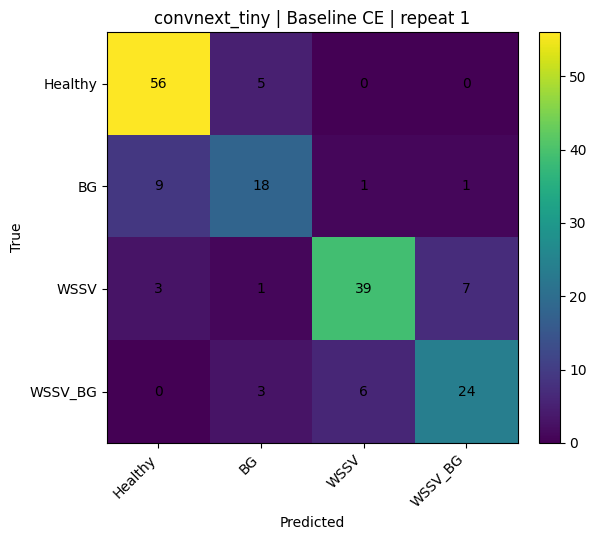

Recorded result:


,Repeat,Seed,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,1,42,convnext_tiny,timm,convnext_tiny,Baseline CE,baseline_ce,Default CrossEntropyLoss,val_macro_f1,28.22,677.8,29,0.463389,0.881047,0.8895,0.8895,0.8863,0.8779,0.881,0.8481,0.7919,0.772,0.7615,0.7655,0.7122,9.4603,18.29,54.6836,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/checkpoints/best_repeat01_convnext_tiny_baseline_ce.pth,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat01_convnext_tiny_baseline_ce.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat01_convnext_tiny_baseline_ce.csv,,,



Training TIMM classifier: convnext_tiny | ASL | repeat 1/3


Resolved TIMM model: convnext_tiny | pretrained=True
[GPU] convnext_tiny ASL after model.to(device): torch CUDA memory allocated/reserved/max: 125.8/148.0/1602.8 MB | nvidia-smi util=8% mem=1569/24564 MB power=58.06 W temp=49 C


convnext_tiny ASL repeat 1 epoch 1/30:   0%|          | 0/26 [00:00<?, ?it/s]

...

Epoch 28/30 | Phase: finetune | LR: 9.57e-06,4.78e-05 | Train Loss: 0.0191 - Acc: 0.9963 | Val Loss: 0.4384 - Acc: 0.8430 - Macro F1: 0.8319
  --> No improvement (1/15)


convnext_tiny ASL repeat 1 epoch 29/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 29/30 | Phase: finetune | LR: 9.57e-06,4.78e-05 | Train Loss: 0.0220 - Acc: 0.9975 | Val Loss: 0.4296 - Acc: 0.8895 - Macro F1: 0.8810
  --> Saved best checkpoint: val macro F1 0.8810, val loss 0.4296


convnext_tiny ASL repeat 1 epoch 30/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 30/30 | Phase: finetune | LR: 8.61e-06,4.30e-05 | Train Loss: 0.0185 - Acc: 0.9963 | Val Loss: 0.4341 - Acc: 0.8779 - Macro F1: 0.8701
  --> No improvement (1/15)


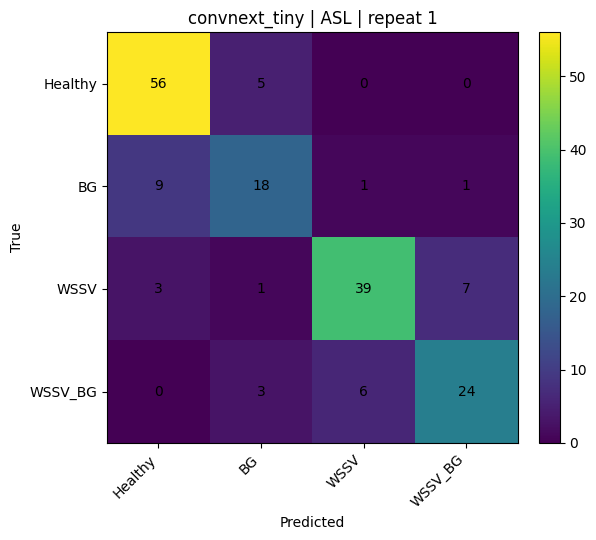

Recorded result:


,Repeat,Seed,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,1,42,convnext_tiny,timm,convnext_tiny,ASL,asl,Asymmetric Loss For Multi-Label Classification,val_macro_f1,28.22,606.6,29,0.429587,0.881047,0.8895,0.8895,0.8863,0.8779,0.881,0.8481,0.7919,0.772,0.7615,0.7655,0.7122,6.6217,26.13,38.2758,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/checkpoints/best_repeat01_convnext_tiny_asl.pth,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat01_convnext_tiny_asl.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat01_convnext_tiny_asl.csv,,,



Training YOLO classifier: yolo26m-cls | Baseline CE | repeat 1/3
[GPU] yolo26m-cls Baseline CE before YOLO train: torch CUDA memory allocated/reserved/max: 17.2/42.0/1602.8 MB | nvidia-smi util=4% mem=1475/24564 MB power=65.62 W temp=50 C
New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24072MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5

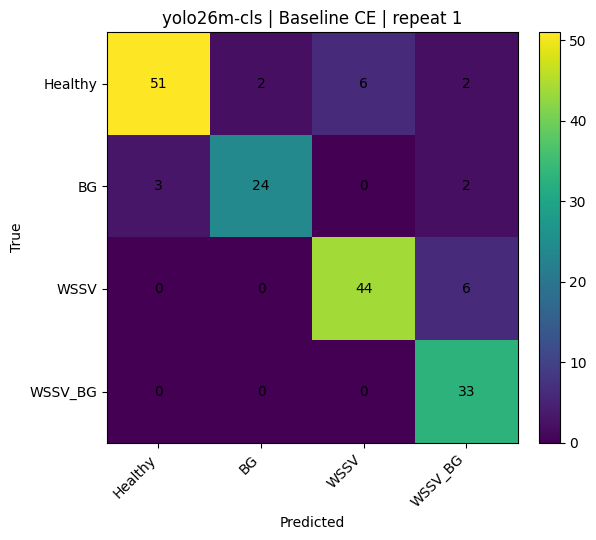

Recorded result:


,Repeat,Seed,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,1,42,yolo26m-cls,yolo,yolo26m-cls.pt,Baseline CE,baseline_ce,Default CrossEntropyLoss,ultralytics_default_best_pt,10.35,226.7,27,0.62158,0.812637,0.8256,0.8256,0.8205,0.8097,0.8126,0.7608,0.8786,0.8787,0.8859,0.877,0.8346,12.2204,14.16,70.6379,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_runs/repeat01_yolo26m-cls_baseline_ce/weights/best.pt,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat01_yolo26m-cls_baseline_ce.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat01_yolo26m-cls_baseline_ce.csv,,,



Training YOLO classifier: yolo26m-cls | ASL | repeat 1/3
[GPU] yolo26m-cls ASL before YOLO train: torch CUDA memory allocated/reserved/max: 17.3/44.0/4567.7 MB | nvidia-smi util=60% mem=1477/24564 MB power=182.11 W temp=52 C
New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24072MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, 

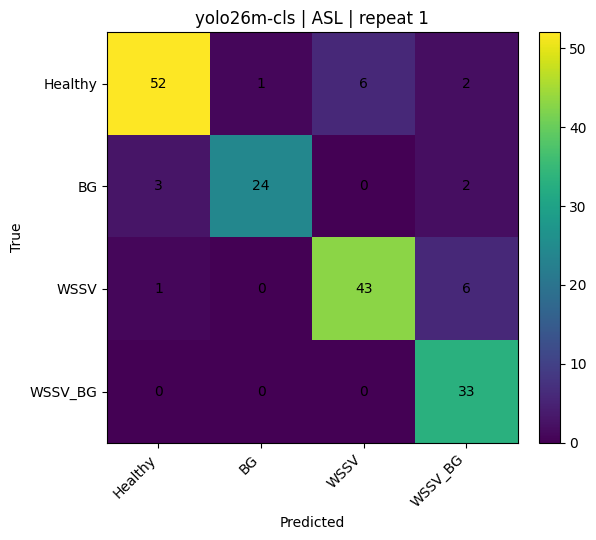

Recorded result:


,Repeat,Seed,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,1,42,yolo26m-cls,yolo,yolo26m-cls.pt,ASL,asl,Asymmetric Loss For Multi-Label Classification,ultralytics_default_best_pt,10.35,221.1,29,0.49876,0.824388,0.8372,0.8372,0.8278,0.8239,0.8244,0.7772,0.8786,0.8834,0.885,0.8787,0.8343,11.5949,14.92,67.0223,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_runs/repeat01_yolo26m-cls_asl/weights/best.pt,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat01_yolo26m-cls_asl.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat01_yolo26m-cls_asl.csv,,,



Training TIMM classifier: convnext_tiny | Baseline CE | repeat 2/3
Resolved TIMM model: convnext_tiny | pretrained=True
[GPU] convnext_tiny Baseline CE after model.to(device): torch CUDA memory allocated/reserved/max: 125.8/148.0/4567.7 MB | nvidia-smi util=5% mem=1573/24564 MB power=55.65 W temp=51 C


convnext_tiny Baseline CE repeat 2 epoch 1/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 01/30 | Phase: warmup | LR: 1.00e-03 | Train Loss: 1.3769 - Acc: 0.4005 | Val Loss: 1.0277 - Acc: 0.5407 - Macro F1: 0.4461
  --> Saved best checkpoint: val macro F1 0.4461, val loss 1.0277


...

Epoch 28/30 | Phase: finetune | LR: 9.57e-06,4.78e-05 | Train Loss: 0.0204 - Acc: 0.9963 | Val Loss: 0.4762 - Acc: 0.8314 - Macro F1: 0.8205
  --> No improvement (3/15)


convnext_tiny Baseline CE repeat 2 epoch 29/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 29/30 | Phase: finetune | LR: 9.57e-06,4.78e-05 | Train Loss: 0.0232 - Acc: 0.9975 | Val Loss: 0.4634 - Acc: 0.8895 - Macro F1: 0.8810
  --> Saved best checkpoint: val macro F1 0.8810, val loss 0.4634


convnext_tiny Baseline CE repeat 2 epoch 30/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 30/30 | Phase: finetune | LR: 8.61e-06,4.30e-05 | Train Loss: 0.0196 - Acc: 0.9963 | Val Loss: 0.4740 - Acc: 0.8721 - Macro F1: 0.8642
  --> No improvement (1/15)


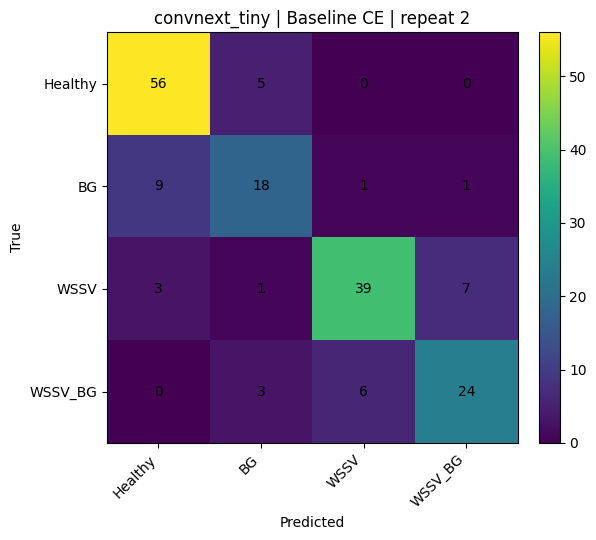

Recorded result:


,Repeat,Seed,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,2,42,convnext_tiny,timm,convnext_tiny,Baseline CE,baseline_ce,Default CrossEntropyLoss,val_macro_f1,28.22,623.8,29,0.463389,0.881047,0.8895,0.8895,0.8863,0.8779,0.881,0.8481,0.7919,0.772,0.7615,0.7655,0.7122,7.0832,24.42,40.9435,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/checkpoints/best_repeat02_convnext_tiny_baseline_ce.pth,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat02_convnext_tiny_baseline_ce.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat02_convnext_tiny_baseline_ce.csv,,,



Training TIMM classifier: convnext_tiny | ASL | repeat 2/3
Resolved TIMM model: convnext_tiny | pretrained=True
[GPU] convnext_tiny ASL after model.to(device): torch CUDA memory allocated/reserved/max: 125.8/148.0/4567.7 MB | nvidia-smi util=33% mem=1652/24564 MB power=54.20 W temp=50 C


convnext_tiny ASL repeat 2 epoch 1/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 01/30 | Phase: warmup | LR: 1.00e-03 | Train Loss: 1.2745 - Acc: 0.4017 | Val Loss: 0.9516 - Acc: 0.5407 - Macro F1: 0.4461
  --> Saved best checkpoint: val macro F1 0.4461, val loss 0.9516


...

Epoch 28/30 | Phase: finetune | LR: 9.57e-06,4.78e-05 | Train Loss: 0.0191 - Acc: 0.9963 | Val Loss: 0.4384 - Acc: 0.8430 - Macro F1: 0.8319
  --> No improvement (1/15)


convnext_tiny ASL repeat 2 epoch 29/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 29/30 | Phase: finetune | LR: 9.57e-06,4.78e-05 | Train Loss: 0.0220 - Acc: 0.9975 | Val Loss: 0.4296 - Acc: 0.8895 - Macro F1: 0.8810
  --> Saved best checkpoint: val macro F1 0.8810, val loss 0.4296


convnext_tiny ASL repeat 2 epoch 30/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 30/30 | Phase: finetune | LR: 8.61e-06,4.30e-05 | Train Loss: 0.0185 - Acc: 0.9963 | Val Loss: 0.4341 - Acc: 0.8779 - Macro F1: 0.8701
  --> No improvement (1/15)


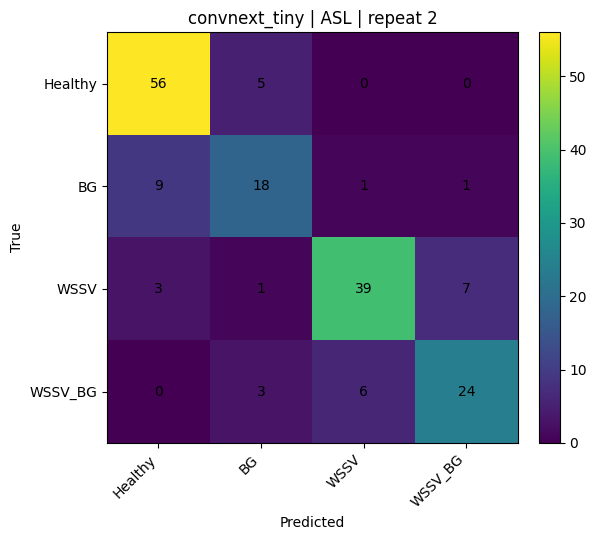

Recorded result:


,Repeat,Seed,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,2,42,convnext_tiny,timm,convnext_tiny,ASL,asl,Asymmetric Loss For Multi-Label Classification,val_macro_f1,28.22,624.2,29,0.429587,0.881047,0.8895,0.8895,0.8863,0.8779,0.881,0.8481,0.7919,0.772,0.7615,0.7655,0.7122,7.0681,24.48,40.8562,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/checkpoints/best_repeat02_convnext_tiny_asl.pth,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat02_convnext_tiny_asl.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat02_convnext_tiny_asl.csv,,,



Training YOLO classifier: yolo26m-cls | Baseline CE | repeat 2/3
[GPU] yolo26m-cls Baseline CE before YOLO train: torch CUDA memory allocated/reserved/max: 17.3/44.0/4567.7 MB | nvidia-smi util=39% mem=1477/24564 MB power=65.40 W temp=50 C
New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24072MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.

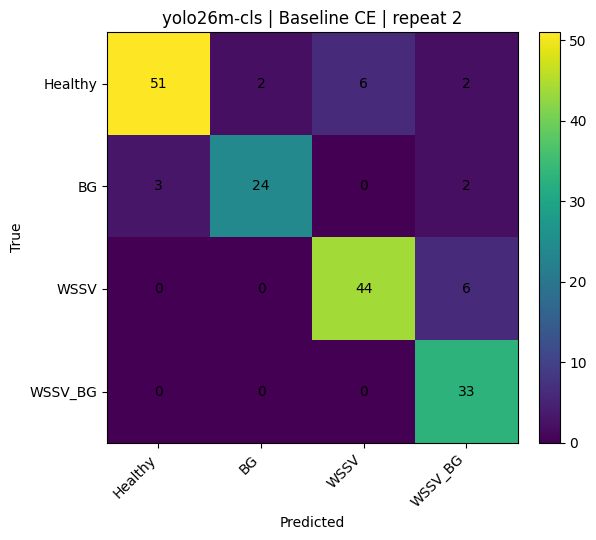

Recorded result:


,Repeat,Seed,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,2,42,yolo26m-cls,yolo,yolo26m-cls.pt,Baseline CE,baseline_ce,Default CrossEntropyLoss,ultralytics_default_best_pt,10.35,219.8,27,0.62158,0.812637,0.8256,0.8256,0.8205,0.8097,0.8126,0.7608,0.8786,0.8787,0.8859,0.877,0.8346,11.7385,14.74,67.8528,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_runs/repeat02_yolo26m-cls_baseline_ce/weights/best.pt,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat02_yolo26m-cls_baseline_ce.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat02_yolo26m-cls_baseline_ce.csv,,,



Training YOLO classifier: yolo26m-cls | ASL | repeat 2/3
[GPU] yolo26m-cls ASL before YOLO train: torch CUDA memory allocated/reserved/max: 17.3/44.0/4567.7 MB | nvidia-smi util=23% mem=1457/24564 MB power=64.43 W temp=51 C
New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24072MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, f

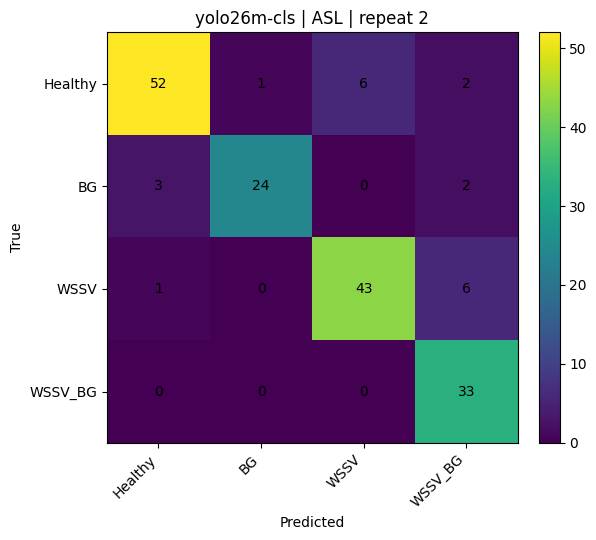

Recorded result:


,Repeat,Seed,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,2,42,yolo26m-cls,yolo,yolo26m-cls.pt,ASL,asl,Asymmetric Loss For Multi-Label Classification,ultralytics_default_best_pt,10.35,189.9,29,0.49876,0.824388,0.8372,0.8372,0.8278,0.8239,0.8244,0.7772,0.8786,0.8834,0.885,0.8787,0.8343,11.0905,15.6,64.1071,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_runs/repeat02_yolo26m-cls_asl/weights/best.pt,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat02_yolo26m-cls_asl.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat02_yolo26m-cls_asl.csv,,,



Training TIMM classifier: convnext_tiny | Baseline CE | repeat 3/3
Resolved TIMM model: convnext_tiny | pretrained=True
[GPU] convnext_tiny Baseline CE after model.to(device): torch CUDA memory allocated/reserved/max: 125.8/148.0/4567.7 MB | nvidia-smi util=4% mem=1665/24564 MB power=56.12 W temp=51 C


convnext_tiny Baseline CE repeat 3 epoch 1/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 01/30 | Phase: warmup | LR: 1.00e-03 | Train Loss: 1.3769 - Acc: 0.4005 | Val Loss: 1.0277 - Acc: 0.5407 - Macro F1: 0.4461
  --> Saved best checkpoint: val macro F1 0.4461, val loss 1.0277


...

Epoch 28/30 | Phase: finetune | LR: 9.57e-06,4.78e-05 | Train Loss: 0.0204 - Acc: 0.9963 | Val Loss: 0.4762 - Acc: 0.8314 - Macro F1: 0.8205
  --> No improvement (3/15)


convnext_tiny Baseline CE repeat 3 epoch 29/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 29/30 | Phase: finetune | LR: 9.57e-06,4.78e-05 | Train Loss: 0.0232 - Acc: 0.9975 | Val Loss: 0.4634 - Acc: 0.8895 - Macro F1: 0.8810
  --> Saved best checkpoint: val macro F1 0.8810, val loss 0.4634


convnext_tiny Baseline CE repeat 3 epoch 30/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 30/30 | Phase: finetune | LR: 8.61e-06,4.30e-05 | Train Loss: 0.0196 - Acc: 0.9963 | Val Loss: 0.4740 - Acc: 0.8721 - Macro F1: 0.8642
  --> No improvement (1/15)


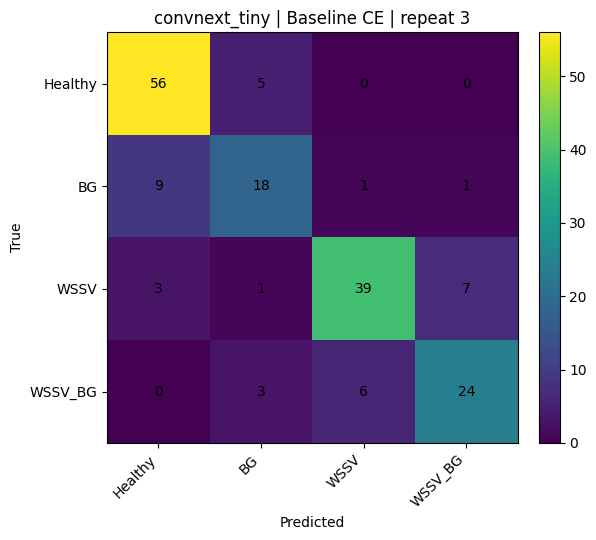

Recorded result:


,Repeat,Seed,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,3,42,convnext_tiny,timm,convnext_tiny,Baseline CE,baseline_ce,Default CrossEntropyLoss,val_macro_f1,28.22,609.0,29,0.463389,0.881047,0.8895,0.8895,0.8863,0.8779,0.881,0.8481,0.7919,0.772,0.7615,0.7655,0.7122,7.157,24.17,41.3697,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/checkpoints/best_repeat03_convnext_tiny_baseline_ce.pth,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat03_convnext_tiny_baseline_ce.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat03_convnext_tiny_baseline_ce.csv,,,



Training TIMM classifier: convnext_tiny | ASL | repeat 3/3
Resolved TIMM model: convnext_tiny | pretrained=True
[GPU] convnext_tiny ASL after model.to(device): torch CUDA memory allocated/reserved/max: 125.8/148.0/4567.7 MB | nvidia-smi util=4% mem=1608/24564 MB power=54.64 W temp=50 C


convnext_tiny ASL repeat 3 epoch 1/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 01/30 | Phase: warmup | LR: 1.00e-03 | Train Loss: 1.2745 - Acc: 0.4017 | Val Loss: 0.9516 - Acc: 0.5407 - Macro F1: 0.4461
  --> Saved best checkpoint: val macro F1 0.4461, val loss 0.9516


...

Epoch 28/30 | Phase: finetune | LR: 9.57e-06,4.78e-05 | Train Loss: 0.0191 - Acc: 0.9963 | Val Loss: 0.4384 - Acc: 0.8430 - Macro F1: 0.8319
  --> No improvement (1/15)


convnext_tiny ASL repeat 3 epoch 29/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 29/30 | Phase: finetune | LR: 9.57e-06,4.78e-05 | Train Loss: 0.0220 - Acc: 0.9975 | Val Loss: 0.4296 - Acc: 0.8895 - Macro F1: 0.8810
  --> Saved best checkpoint: val macro F1 0.8810, val loss 0.4296


convnext_tiny ASL repeat 3 epoch 30/30:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 30/30 | Phase: finetune | LR: 8.61e-06,4.30e-05 | Train Loss: 0.0185 - Acc: 0.9963 | Val Loss: 0.4341 - Acc: 0.8779 - Macro F1: 0.8701
  --> No improvement (1/15)


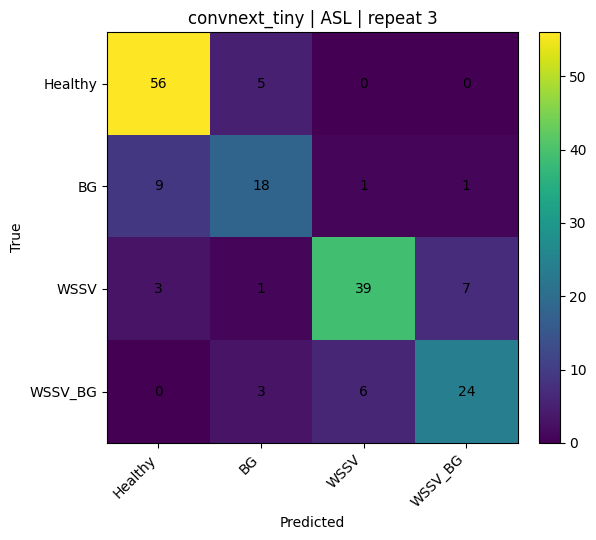

Recorded result:


,Repeat,Seed,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,3,42,convnext_tiny,timm,convnext_tiny,ASL,asl,Asymmetric Loss For Multi-Label Classification,val_macro_f1,28.22,608.4,29,0.429587,0.881047,0.8895,0.8895,0.8863,0.8779,0.881,0.8481,0.7919,0.772,0.7615,0.7655,0.7122,7.1105,24.33,41.1013,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/checkpoints/best_repeat03_convnext_tiny_asl.pth,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat03_convnext_tiny_asl.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat03_convnext_tiny_asl.csv,,,



Training YOLO classifier: yolo26m-cls | Baseline CE | repeat 3/3
[GPU] yolo26m-cls Baseline CE before YOLO train: torch CUDA memory allocated/reserved/max: 17.3/44.0/4567.7 MB | nvidia-smi util=9% mem=1466/24564 MB power=69.63 W temp=50 C
New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24072MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5

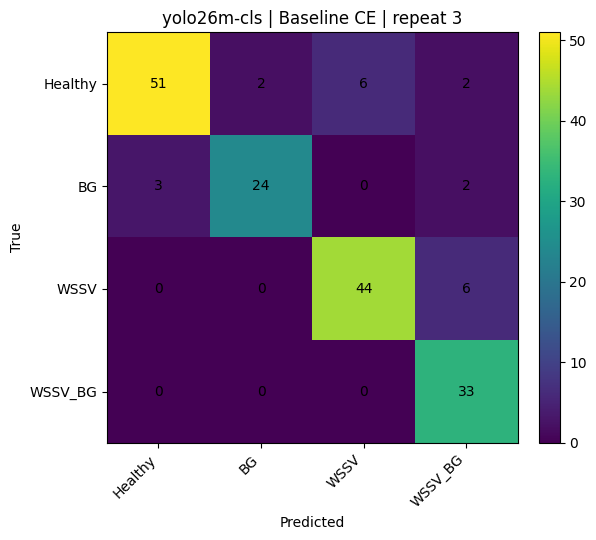

Recorded result:


,Repeat,Seed,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,3,42,yolo26m-cls,yolo,yolo26m-cls.pt,Baseline CE,baseline_ce,Default CrossEntropyLoss,ultralytics_default_best_pt,10.35,194.7,27,0.62158,0.812637,0.8256,0.8256,0.8205,0.8097,0.8126,0.7608,0.8786,0.8787,0.8859,0.877,0.8346,10.661,16.23,61.6244,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_runs/repeat03_yolo26m-cls_baseline_ce/weights/best.pt,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat03_yolo26m-cls_baseline_ce.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat03_yolo26m-cls_baseline_ce.csv,,,



Training YOLO classifier: yolo26m-cls | ASL | repeat 3/3
[GPU] yolo26m-cls ASL before YOLO train: torch CUDA memory allocated/reserved/max: 17.3/44.0/4567.7 MB | nvidia-smi util=34% mem=1541/24564 MB power=65.12 W temp=51 C
New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.21 🚀 Python-3.13.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24072MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, f

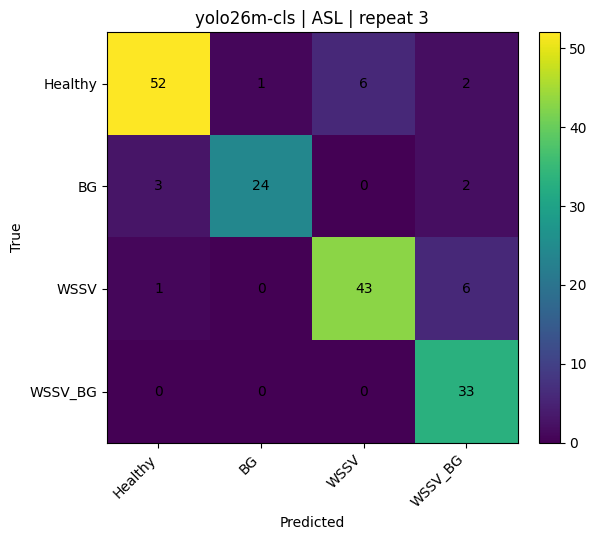

Recorded result:


,Repeat,Seed,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,3,42,yolo26m-cls,yolo,yolo26m-cls.pt,ASL,asl,Asymmetric Loss For Multi-Label Classification,ultralytics_default_best_pt,10.35,192.2,29,0.49876,0.824388,0.8372,0.8372,0.8278,0.8239,0.8244,0.7772,0.8786,0.8834,0.885,0.8787,0.8343,10.6554,16.24,61.5919,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_runs/repeat03_yolo26m-cls_asl/weights/best.pt,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat03_yolo26m-cls_asl.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat03_yolo26m-cls_asl.csv,,,


In [9]:
TARGET_RUNS = []
for repeat_id in range(1, REPEATS + 1):
    for model_name in TIMM_MODELS:
        for loss_name in LOSS_RUNS:
            TARGET_RUNS.append({"Repeat": repeat_id, "Model": model_name, "Backend": "timm", "Loss": loss_name})
    for model_name in YOLO_MODELS:
        for loss_name in LOSS_RUNS:
            TARGET_RUNS.append({"Repeat": repeat_id, "Model": model_name, "Backend": "yolo", "Loss": loss_name})

comparison_results = []
all_histories = []

for spec in TARGET_RUNS:
    repeat_id = spec["Repeat"]
    model_name = spec["Model"]
    backend = spec["Backend"]
    loss_name = spec["Loss"]
    try:
        if backend == "timm":
            result, history = train_timm_model(model_name, loss_name, repeat_id)
        elif backend == "yolo":
            result, history = train_yolo_model(model_name, loss_name, repeat_id)
        else:
            raise ValueError(backend)
        comparison_results.append(result)
        all_histories.extend(history)
        print("Recorded result:")
        display(pd.DataFrame([result]))
    except Exception as exc:
        print(f"ERROR while running repeat {repeat_id} | {model_name} | {backend} | {LOSS_LABELS[loss_name]}: {type(exc).__name__}: {exc}")
        comparison_results.append({"Repeat": repeat_id, "Seed": SEED, "Model": model_name, "Backend": backend, "Backend Name": "", "Loss": LOSS_LABELS[loss_name], "Loss Key": loss_name, "Loss Paper": LOSS_PAPERS[loss_name], "Selection Metric": "run_failed", "Parameters (M)": np.nan, "Training Time (s)": np.nan, "Best Epoch": np.nan, "Best Val Loss": np.nan, "Best Val Macro F1": np.nan, "Best Val Top1": np.nan, "Val Accuracy": np.nan, "Val Precision": np.nan, "Val Recall": np.nan, "Val F1-Score": np.nan, "Val Cohen Kappa": np.nan, "Test Accuracy": np.nan, "Test Precision": np.nan, "Test Recall": np.nan, "Test F1-Score": np.nan, "Cohen Kappa": np.nan, "Inference Time (s)": np.nan, "FPS": np.nan, "Latency (ms)": np.nan, "Checkpoint Path": "", "Confusion Matrix Path": "", "Classification Report Path": "", "Export Format": "not_run", "Export Path": "", "Export Note": f"Run failed: {type(exc).__name__}: {exc}"})
    partial_df = pd.DataFrame(comparison_results)
    partial_df.to_csv(REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_repeat3_partial.csv", index=False)
    partial_df.to_json(REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_repeat3_partial.json", orient="records", indent=2)
    if all_histories:
        pd.DataFrame(all_histories).to_csv(REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_repeat3_history_partial.csv", index=False)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

In [10]:
df_summary = pd.DataFrame(comparison_results)
metric_columns = ["Repeat", "Seed", "Model", "Backend", "Loss", "Selection Metric", "Parameters (M)", "Training Time (s)", "Best Epoch", "Best Val Loss", "Best Val Macro F1", "Best Val Top1", "Val Accuracy", "Val Precision", "Val Recall", "Val F1-Score", "Val Cohen Kappa", "Test Accuracy", "Test Precision", "Test Recall", "Test F1-Score", "Cohen Kappa", "Inference Time (s)", "FPS", "Latency (ms)", "Checkpoint Path", "Confusion Matrix Path", "Classification Report Path"]

if not df_summary.empty:
    for col in metric_columns:
        if col not in df_summary.columns:
            df_summary[col] = np.nan
    df_summary = df_summary.sort_values(by=["Repeat", "Backend", "Model", "Loss Key"], ascending=[True, True, True, True], na_position="last").reset_index(drop=True)
    display(df_summary[metric_columns])
    summary_csv = REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_repeat3_summary.csv"
    summary_json = REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_repeat3_summary.json"
    metrics_csv = REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_repeat3_metrics_table.csv"
    df_summary.to_csv(summary_csv, index=False)
    df_summary.to_json(summary_json, orient="records", indent=2)
    df_summary[metric_columns].to_csv(metrics_csv, index=False)
    print(f"Saved summary CSV: {summary_csv}")
    print(f"Saved summary JSON: {summary_json}")
    print(f"Saved metrics-only CSV: {metrics_csv}")
    numeric_metrics = ["Best Epoch", "Best Val Loss", "Best Val Macro F1", "Best Val Top1", "Val Accuracy", "Val Precision", "Val Recall", "Val F1-Score", "Val Cohen Kappa", "Test Accuracy", "Test Precision", "Test Recall", "Test F1-Score", "Cohen Kappa", "Inference Time (s)", "FPS", "Latency (ms)"]
    repro_rows = []
    for (model, backend, loss), group in df_summary.groupby(["Model", "Backend", "Loss"]):
        row = {"Model": model, "Backend": backend, "Loss": loss, "Runs": len(group), "Completed Runs": int(group["Test F1-Score"].notna().sum())}
        for metric in numeric_metrics:
            values = pd.to_numeric(group[metric], errors="coerce").dropna()
            row[f"{metric} Mean"] = values.mean() if len(values) else np.nan
            row[f"{metric} Std"] = values.std(ddof=0) if len(values) else np.nan
            row[f"{metric} Min"] = values.min() if len(values) else np.nan
            row[f"{metric} Max"] = values.max() if len(values) else np.nan
        repro_rows.append(row)
    repro_df = pd.DataFrame(repro_rows)
    repro_csv = REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_repeat3_reproducibility_stats.csv"
    repro_df.to_csv(repro_csv, index=False)
    display(repro_df)
    print(f"Saved reproducibility stats: {repro_csv}")
    if all_histories:
        history_df = pd.DataFrame(all_histories)
        history_csv = REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_repeat3_history.csv"
        history_df.to_csv(history_csv, index=False)
        display(history_df.head())
        print(f"Saved history CSV: {history_csv}")
else:
    print("No model results were produced.")

,Repeat,Seed,Model,Backend,Loss,Selection Metric,Parameters (M),Training Time (s),Best Epoch,Best Val Loss,Best Val Macro F1,Best Val Top1,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path
0,1,42,convnext_tiny,timm,ASL,val_macro_f1,28.22,606.6,29,0.429587,0.881047,0.8895,0.8895,0.8863,0.8779,0.8810,0.8481,0.7919,0.7720,0.7615,0.7655,0.7122,6.6217,26.13,38.2758,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/checkpoints/best_repeat01_convnext_tiny_asl.pth,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat01_convnext_tiny_asl.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat01_convnext_tiny_asl.csv
1,1,42,convnext_tiny,timm,Baseline CE,val_macro_f1,28.22,677.8,29,0.463389,0.881047,0.8895,0.8895,0.8863,0.8779,0.8810,0.8481,0.7919,0.7720,0.7615,0.7655,0.7122,9.4603,18.29,54.6836,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/checkpoints/best_repeat01_convnext_tiny_baseline_ce.pth,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat01_convnext_tiny_baseline_ce.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat01_convnext_tiny_baseline_ce.csv
2,1,42,yolo26m-cls,yolo,ASL,ultralytics_default_best_pt,10.35,221.1,29,0.498760,0.824388,0.8372,0.8372,0.8278,0.8239,0.8244,0.7772,0.8786,0.8834,0.8850,0.8787,0.8343,11.5949,14.92,67.0223,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_runs/repeat01_yolo26m-cls_asl/weights/best.pt,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat01_yolo26m-cls_asl.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat01_yolo26m-cls_asl.csv
3,1,42,yolo26m-cls,yolo,Baseline CE,ultralytics_default_best_pt,10.35,226.7,27,0.621580,0.812637,0.8256,0.8256,0.8205,0.8097,0.8126,0.7608,0.8786,0.8787,0.8859,0.8770,0.8346,12.2204,14.16,70.6379,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/yolo_runs/repeat01_yolo26m-cls_baseline_ce/weights/best.pt,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat01_yolo26m-cls_baseline_ce.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat01_yolo26m-cls_baseline_ce.csv
4,2,42,convnext_tiny,timm,ASL,val_macro_f1,28.22,624.2,29,0.429587,0.881047,0.8895,0.8895,0.8863,0.8779,0.8810,0.8481,0.7919,0.7720,0.7615,0.7655,0.7122,7.0681,24.48,40.8562,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/checkpoints/best_repeat02_convnext_tiny_asl.pth,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/plots/confusion_matrix_repeat02_convnext_tiny_asl.png,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/classification_report_repeat02_convnext_tiny_asl.csv
5,2,42,convnext_tiny,timm,Baseline CE,val_macro_f1,28.22,623.8,29,0.463389,0.881047,0.8895,0.8895,0.8863,0.8779,0.8810,0.8481,0.7919,0.7720,0.7615,0.7655,0.7122,7.0832,24.42,40.9435,/home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/checkpoints/best_repeat02_convnext_tiny_baseline_ce.pth,/home/drnguyenvinh/notebooks/

Saved summary CSV: /home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/ce_asl_convnext_tiny_yolo26m_repeat3_summary.csv
Saved summary JSON: /home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/ce_asl_convnext_tiny_yolo26m_repeat3_summary.json
Saved metrics-only CSV: /home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/ce_asl_convnext_tiny_yolo26m_repeat3_metrics_table.csv


,Model,Backend,Loss,Runs,Completed Runs,Best Epoch Mean,Best Epoch Std,Best Epoch Min,Best Epoch Max,Best Val Loss Mean,Best Val Loss Std,Best Val Loss Min,Best Val Loss Max,Best Val Macro F1 Mean,Best Val Macro F1 Std,Best Val Macro F1 Min,Best Val Macro F1 Max,Best Val Top1 Mean,Best Val Top1 Std,Best Val Top1 Min,Best Val Top1 Max,Val Accuracy Mean,Val Accuracy Std,Val Accuracy Min,Val Accuracy Max,Val Precision Mean,Val Precision Std,Val Precision Min,Val Precision Max,Val Recall Mean,Val Recall Std,Val Recall Min,Val Recall Max,Val F1-Score Mean,Val F1-Score Std,Val F1-Score Min,Val F1-Score Max,Val Cohen Kappa Mean,Val Cohen Kappa Std,Val Cohen Kappa Min,Val Cohen Kappa Max,Test Accuracy Mean,Test Accuracy Std,Test Accuracy Min,Test Accuracy Max,Test Precision Mean,Test Precision Std,Test Precision Min,Test Precision Max,Test Recall Mean,Test Recall Std,Test Recall Min,Test Recall Max,Test F1-Score Mean,Test F1-Score Std,Test F1-Score Min,Test F1-Score Max,Cohen Kappa Mean,Cohen Kappa Std,Cohen Kappa Min,Cohen Kappa Max,Inference Time (s) Mean,Inference Time (s) Std,Inference Time (s) Min,Inference Time (s) Max,FPS Mean,FPS Std,FPS Min,FPS Max,Latency (ms) Mean,Latency (ms) Std,Latency (ms) Min,Latency (ms) Max
0,convnext_tiny,timm,ASL,3,3,29.0,0.0,29,29,0.429587,0.000000e+00,0.429587,0.429587,0.881047,0.0,0.881047,0.881047,0.8895,0.0,0.8895,0.8895,0.8895,0.0,0.8895,0.8895,0.8863,0.0,0.8863,0.8863,0.8779,0.0,0.8779,0.8779,0.8810,1.110223e-16,0.8810,0.8810,0.8481,0.0,0.8481,0.8481,0.7919,0.0,0.7919,0.7919,0.7720,1.110223e-16,0.7720,0.7720,0.7615,0.000000e+00,0.7615,0.7615,0.7655,0.000000e+00,0.7655,0.7655,0.7122,0.000000e+00,0.7122,0.7122,6.933433,0.221107,6.6217,7.1105,24.980000,0.815475,24.33,26.13,40.077767,1.278106,38.2758,41.1013
1,convnext_tiny,timm,Baseline CE,3,3,29.0,0.0,29,29,0.463389,0.000000e+00,0.463389,0.463389,0.881047,0.0,0.881047,0.881047,0.8895,0.0,0.8895,0.8895,0.8895,0.0,0.8895,0.8895,0.8863,0.0,0.8863,0.8863,0.8779,0.0,0.8779,0.8779,0.8810,1.110223e-16,0.8810,0.8810,0.8481,0.0,0.8481,0.8481,0.7919,0.0,0.7919,0.7919,0.7720,1.110223e-16,0.7720,0.7720,0.7615,0.000000e+00,0.7615,0.7615,0.7655,0.000000e+00,0.7655,0.7655,0.7122,0.000000e+00,0.7122,0.7122,7.900167,1.103592,7.0832,9.4603,22.293333,2.832623,18.29,24.42,45.665600,6.379062,40.9435,54.6836
2,yolo26m-cls,yolo,ASL,3,3,29.0,0.0,29,29,0.498760,5.551115e-17,0.498760,0.498760,0.824388,0.0,0.824388,0.824388,0.8372,0.0,0.8372,0.8372,0.8372,0.0,0.8372,0.8372,0.8278,0.0,0.8278,0.8278,0.8239,0.0,0.8239,0.8239,0.8244,1.110223e-16,0.8244,0.8244,0.7772,0.0,0.7772,0.7772,0.8786,0.0,0.8786,0.8786,0.8834,0.000000e+00,0.8834,0.8834,0.8850,1.110223e-16,0.8850,0.8850,0.8787,1.110223e-16,0.8787,0.8787,0.8343,1.110223e-16,0.8343,0.8343,11.113600,0.383897,10.6554,11.5949,15.586667,0.538970,14.92,16.24,64.240433,2.218955,61.5919,67.0223
3,yolo26m-cls,yolo,Baseline CE,3,3,27.0,0.0,27,27,0.621580,0.000000e+00,0.621580,0.621580,0.812637,0.0,0.812637,0.812637,0.8256,0.0,0.8256,0.8256,0.8256,0.0,0.8256,0.8256,0.8205,0.0,0.8205,0.8205,0.8097,0.0,0.8097,0.8097,0.8126,1.110223e-16,0.8126,0.8126,0.7608,0.0,0.7608,0.7608,0.8786,0.0,0.8786,0.8786,0.8787,1.110223e-16,0.8787,0.8787,0.8859,0.000000e+00,0.8859,0.8859,0.8770,1.110223e-16,0.8770,0.8770,0.8346,0.000000e+00,0.8346,0.8346,11.539967,0.651917,10.6610,12.2204,15.043333,0.871869,14.16,16.23,66.705033,3.768185,61.6244,70.6379


Saved reproducibility stats: /home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/ce_asl_convnext_tiny_yolo26m_repeat3_reproducibility_stats.csv


,Repeat,Seed,Model,Backend,Loss,Loss Key,Epoch,Phase,LR,Train Loss,Train Accuracy,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1-Score,Val Cohen Kappa,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
0,1,42,convnext_tiny,timm,Baseline CE,baseline_ce,1,warmup,1.00e-03,1.376857,0.400498,1.027694,0.540698,0.678939,0.475572,0.446088,0.336847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,42,convnext_tiny,timm,Baseline CE,baseline_ce,2,warmup,1.00e-03,0.960455,0.599502,0.993535,0.593023,0.666612,0.531586,0.542307,0.412740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,42,convnext_tiny,timm,Baseline CE,baseline_ce,3,warmup,1.00e-03,0.820174,0.655473,0.862862,0.633721,0.611704,0.603463,0.605681,0.494755,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,42,convnext_tiny,timm,Baseline CE,baseline_ce,4,warmup,9.00e-04,0.753647,0.687811,0.832975,0.645349,0.753854,0.566628,0.553145,0.490061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,42,convnext_tiny,timm,Baseline CE,baseline_ce,5,warmup,9.00e-04,0.716813,0.705224,0.858679,0.651163,0.710165,0.586951,0.601741,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved history CSV: /home/drnguyenvinh/notebooks/final_yolo26m_convnext_tiny_ce_asl_original_yolo_best_repeat3_outputs/reports/ce_asl_convnext_tiny_yolo26m_repeat3_history.csv


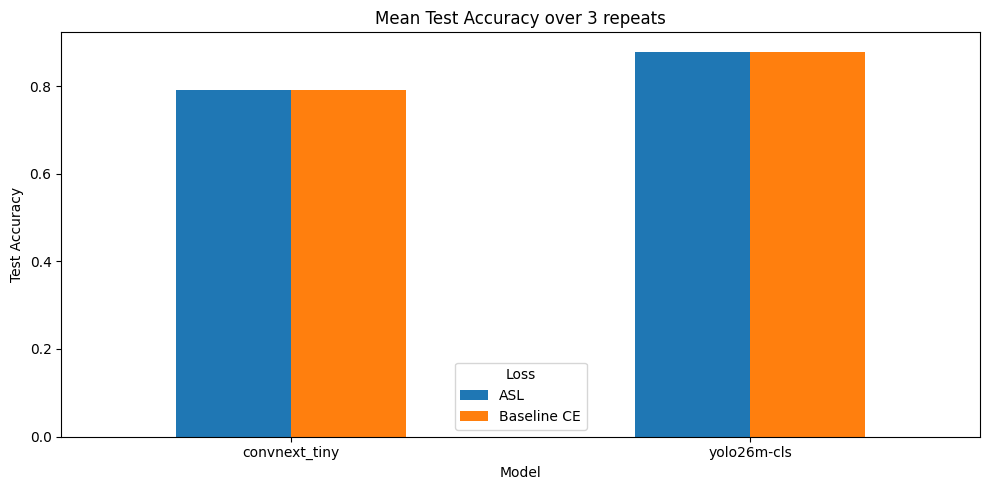

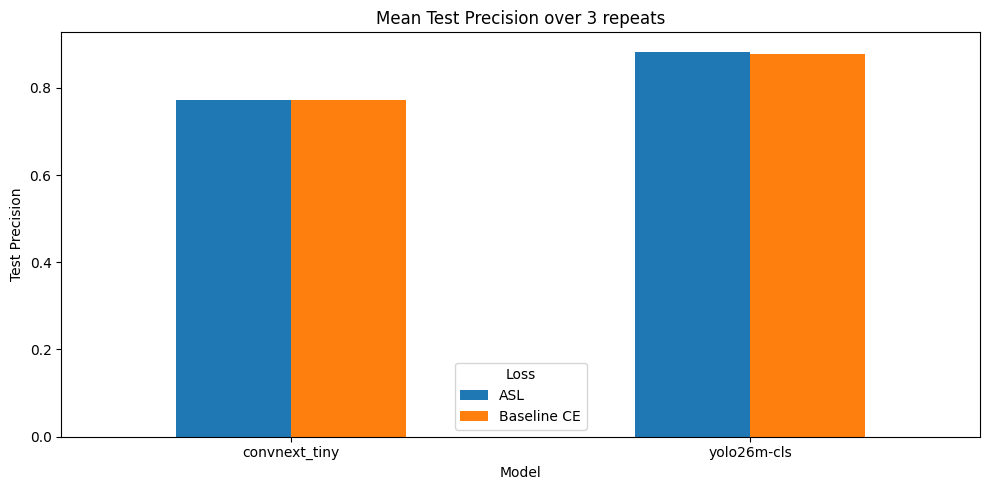

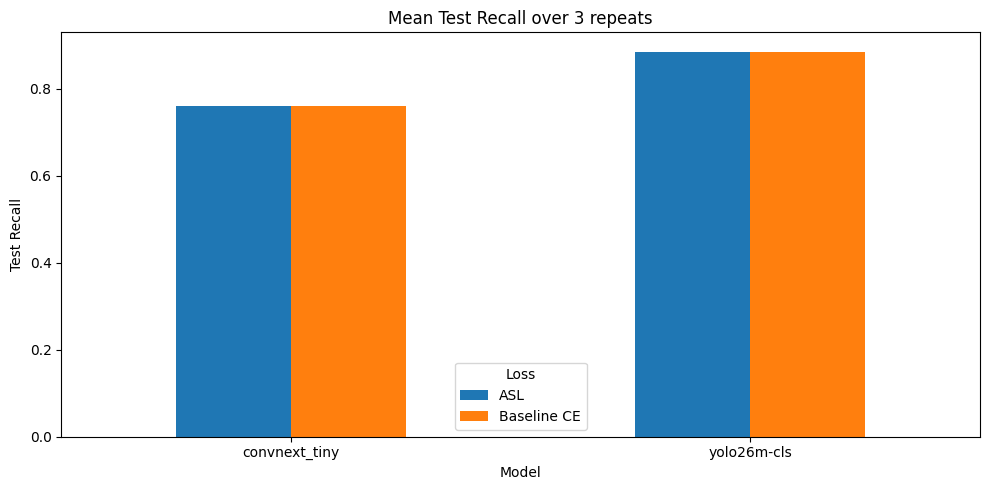

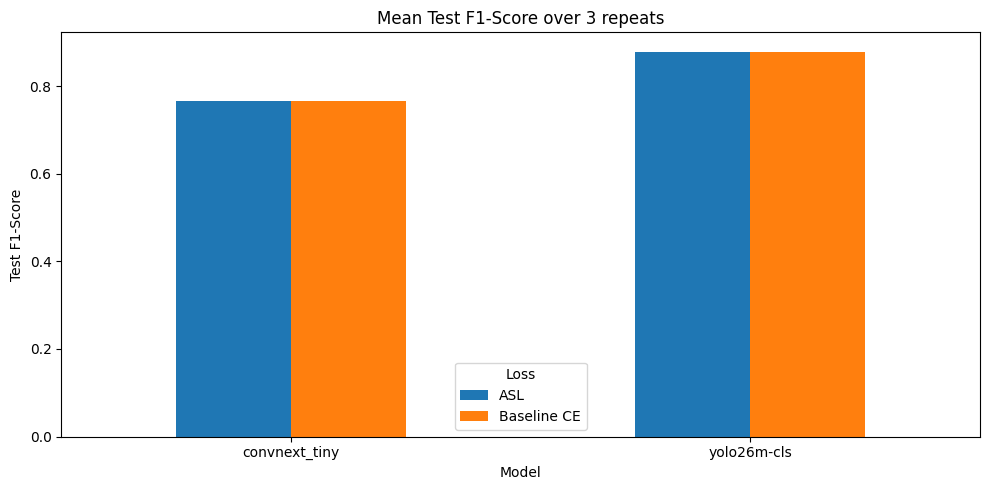

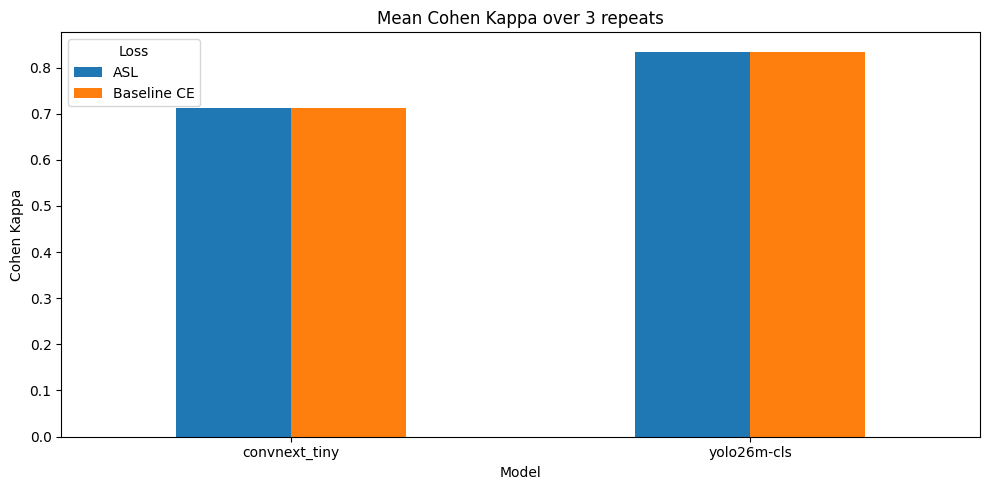

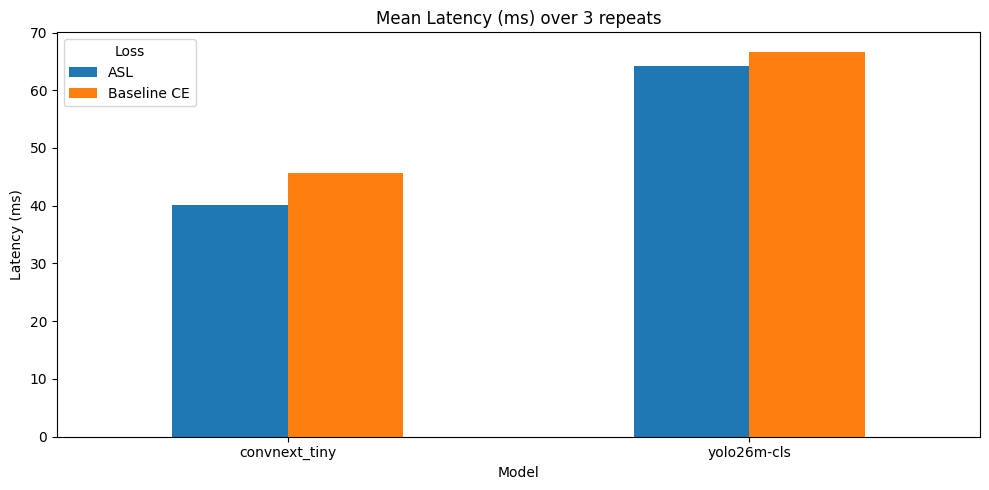

In [11]:
if not df_summary.empty:
    plot_metrics = ["Test Accuracy", "Test Precision", "Test Recall", "Test F1-Score", "Cohen Kappa", "Latency (ms)"]
    for metric in plot_metrics:
        plot_df = df_summary.dropna(subset=[metric]).copy()
        if plot_df.empty:
            continue
        pivot = plot_df.groupby(["Model", "Loss"])[metric].mean().unstack("Loss")
        ax = pivot.plot(kind="bar", figsize=(10, 5))
        ax.set_title(f"Mean {metric} over {REPEATS} repeats")
        ax.set_xlabel("Model")
        ax.set_ylabel(metric)
        ax.legend(title="Loss")
        plt.xticks(rotation=0)
        plt.tight_layout()
        out_path = PLOT_DIR / f"bar_mean_{sanitize_name(metric)}.png"
        plt.savefig(out_path, dpi=180, bbox_inches="tight")
        plt.show()